In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# =========================
# Inputs
# =========================
#csv_files = {
#    "Base": "CNBS_forecast_ver_anom.csv",
#    "SSTs": "CNBS_forecast_ver_anom_sst.csv",
#    "SWEs": "CNBS_forecast_ver_anom_swe.csv",
#    "SSTs/SWEs": "CNBS_forecast_ver_anom_sst_swe.csv",
#}

csv_files = {
    "Base": "CNBS_forecast_val.csv",
    "Bias_Corrected": "CNBS_forecast_ver_bias_corrected.csv",
}

In [3]:
models = ["RF", "GP", "XGB", "NN"]
metrics = ["RMSE", "R2", "Bias"]

version_colors = {
    "Base": "#1a93e9",
    "Bias_Corrected": "#ff8b26",
    #"SSTs": "#ff8b26",
    #"SWEs": "#50da50",
    #"SSTs/SWEs": "#9f16ba",
}

# =========================
# Read and combine CSVs
# =========================
dfs = []

for version_name, path in csv_files.items():
    df = pd.read_csv(path, sep='\t')
    df["version"] = version_name
    dfs.append(df)

#forecast_col = "erie_nbs"
#obs_col = "erie_nbs_obs"

In [4]:
print(dfs[0].columns)

Index(['cfs_run', 'model', 'forecast_month', 'erie_evaporation', 'erie_nbs',
       'erie_precipitation', 'erie_runoff', 'michigan-huron_evaporation',
       'michigan-huron_nbs', 'michigan-huron_precipitation',
       'michigan-huron_runoff', 'ontario_evaporation', 'ontario_nbs',
       'ontario_precipitation', 'ontario_runoff', 'superior_evaporation',
       'superior_nbs', 'superior_precipitation', 'superior_runoff', 'date',
       'superior_evaporation_obs', 'superior_runoff_obs',
       'superior_precipitation_obs', 'michigan-huron_evaporation_obs',
       'michigan-huron_runoff_obs', 'michigan-huron_precipitation_obs',
       'erie_evaporation_obs', 'erie_runoff_obs', 'erie_precipitation_obs',
       'ontario_evaporation_obs', 'ontario_runoff_obs',
       'ontario_precipitation_obs', 'superior_nbs_obs',
       'michigan-huron_nbs_obs', 'erie_nbs_obs', 'ontario_nbs_obs', 'version'],
      dtype='str')


In [5]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score


def calculate_metrics(df, forecast_col, obs_col):
    y_true = df[obs_col]
    y_pred = df[forecast_col]

    valid = y_true.notna() & y_pred.notna()
    y_true = y_true[valid]
    y_pred = y_pred[valid]

    if len(y_true) == 0:
        return {"RMSE": np.nan, "R2": np.nan, "Bias": np.nan}

    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "Bias": np.mean(y_pred - y_true),
    }


# =========================
# Calculate metrics by lake/component
# =========================
lakes = ["superior", "michigan-huron", "erie", "ontario"]
components = ["precipitation", "evaporation", "runoff", "nbs"]

results = []

for version_name, path in csv_files.items():
    df = pd.read_csv(path, sep="\t")

    for model in models:
        df_model = df[df["model"] == model]

        for lake in lakes:
            for component in components:
                forecast_col = f"{lake}_{component}"
                obs_col = f"{lake}_{component}_obs"

                if forecast_col not in df_model.columns or obs_col not in df_model.columns:
                    continue

                metrics = calculate_metrics(
                    df_model,
                    forecast_col=forecast_col,
                    obs_col=obs_col,
                )

                results.append({
                    "version": version_name,
                    "model": model,
                    "lake": lake,
                    "component": component,
                    **metrics
                })

metrics_df = pd.DataFrame(results)

print(metrics_df)

            version model            lake      component        RMSE  \
0              Base    RF        superior  precipitation   25.516296   
1              Base    RF        superior    evaporation   14.344533   
2              Base    RF        superior         runoff   14.162731   
3              Base    RF        superior            nbs   46.046422   
4              Base    RF  michigan-huron  precipitation   23.689628   
..              ...   ...             ...            ...         ...   
123  Bias_Corrected    NN            erie            nbs  153.298277   
124  Bias_Corrected    NN         ontario  precipitation   38.808218   
125  Bias_Corrected    NN         ontario    evaporation   20.091991   
126  Bias_Corrected    NN         ontario         runoff   59.580701   
127  Bias_Corrected    NN         ontario            nbs  150.439929   

           R2       Bias  
0    0.150114  -9.097958  
1    0.901752  -1.028847  
2    0.666266  -1.465629  
3    0.622295  -8.691867  


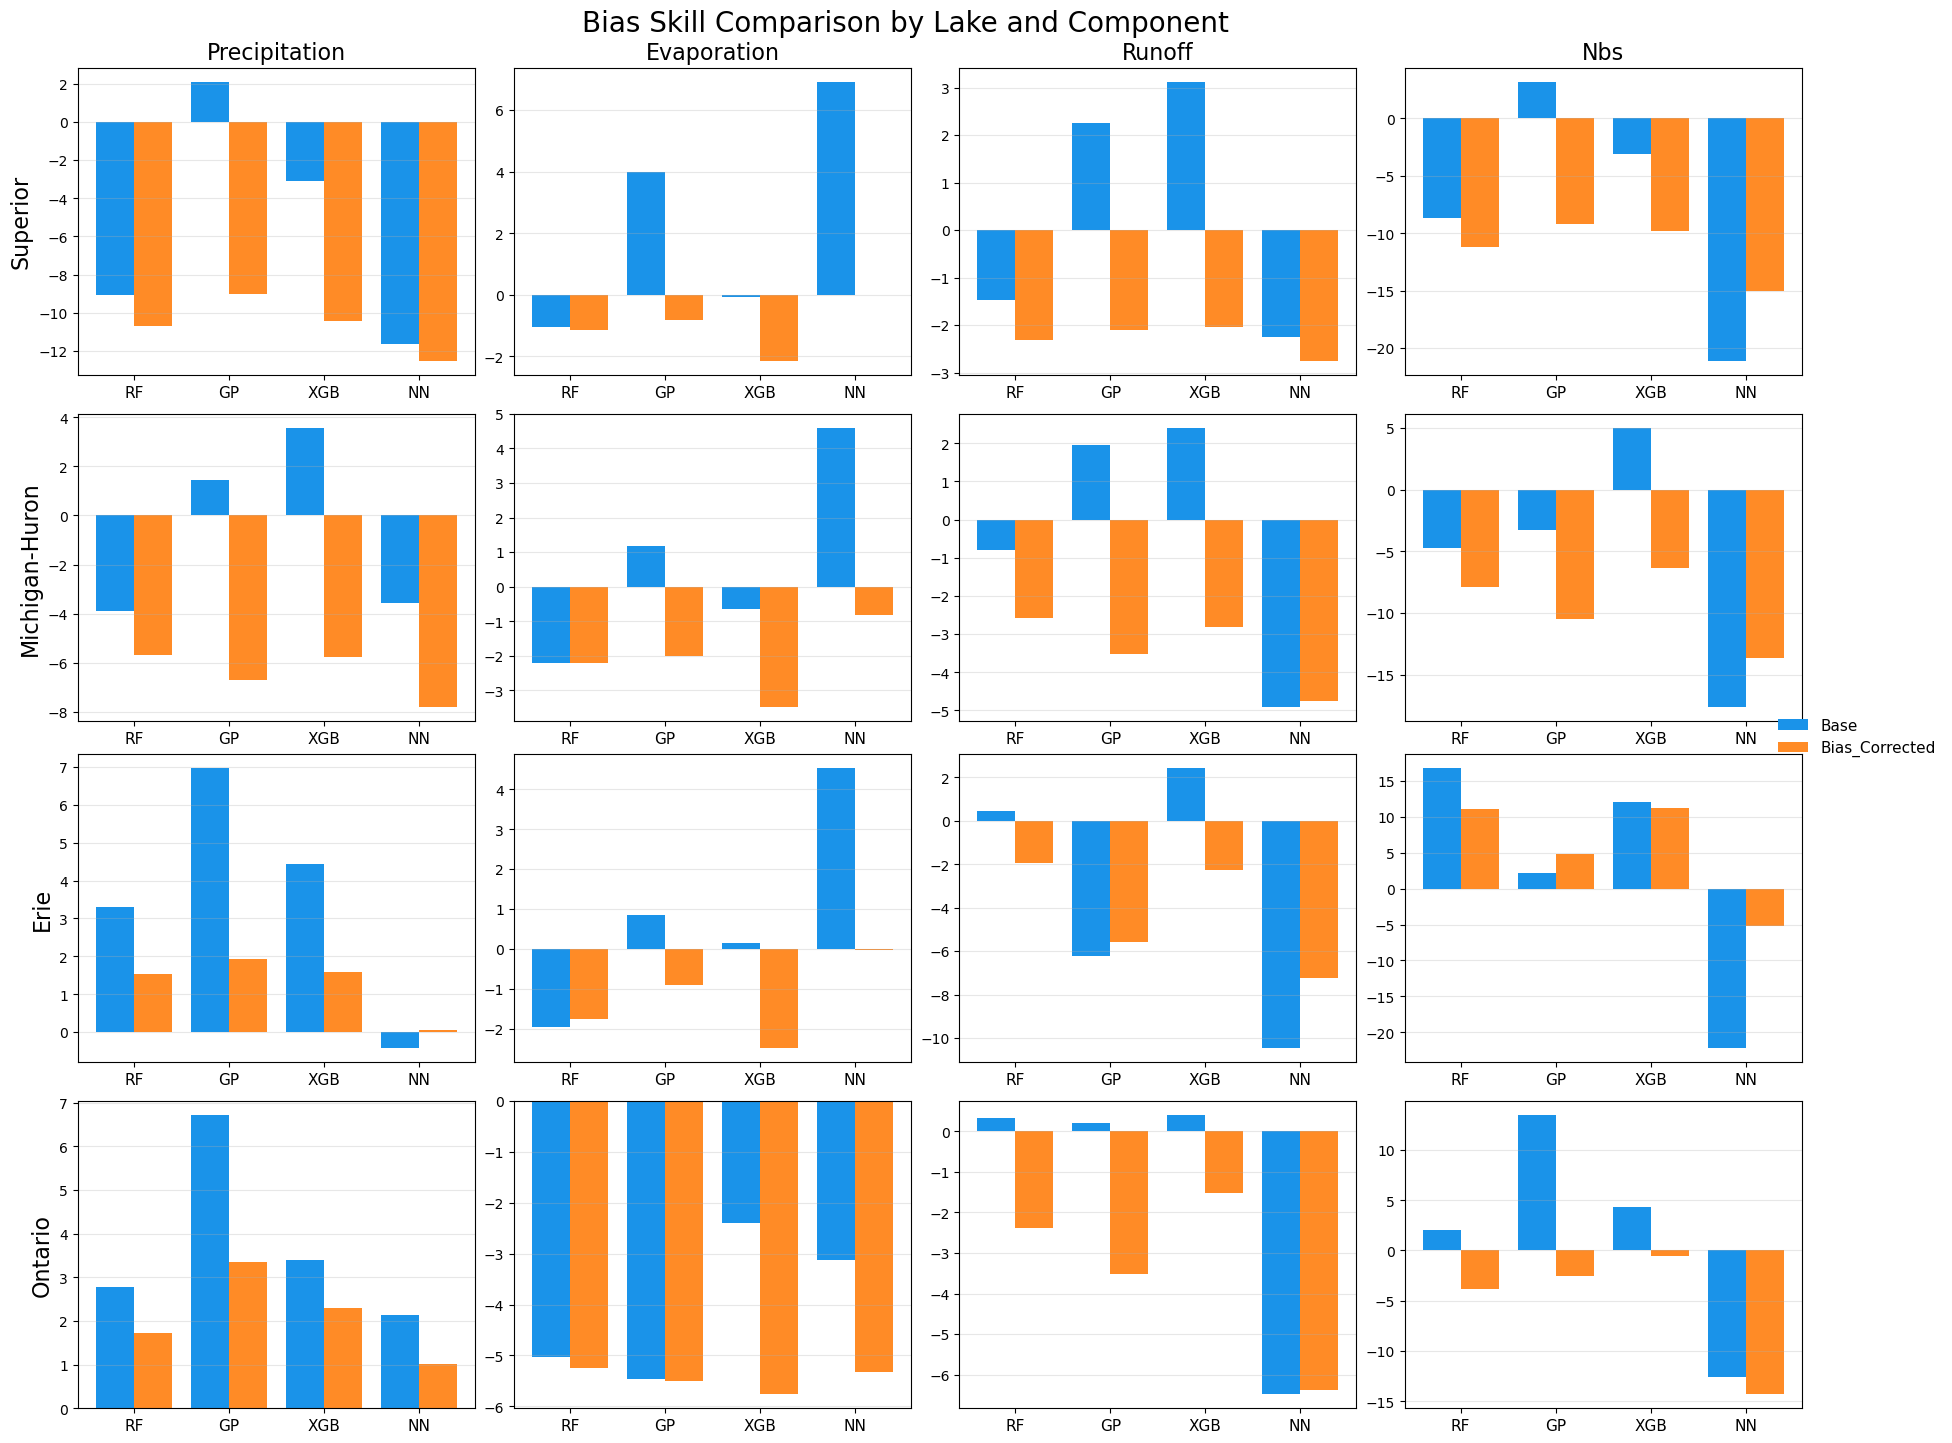

In [6]:
# =========================
# Plot RMSE grouped bars by lake and component
# =========================
metric = "Bias"

lakes = ["superior", "michigan-huron", "erie", "ontario"]
components = ["precipitation", "evaporation", "runoff", "nbs"]
versions = list(metrics_df["version"].unique())

fig, axes = plt.subplots(
    len(lakes),
    len(components),
    figsize=(18, 14),
    constrained_layout=True
)

x = np.arange(len(models))
bar_width = 0.8 / len(versions)

for r, lake in enumerate(lakes):
    for c, component in enumerate(components):
        ax = axes[r, c]

        subset = metrics_df[
            (metrics_df["lake"] == lake) &
            (metrics_df["component"] == component)
        ]

        for i, version in enumerate(versions):
            values = (
                subset[subset["version"] == version]
                .set_index("model")
                .reindex(models)[metric]
            )

            offset = (i - (len(versions) - 1) / 2) * bar_width

            ax.bar(
                x + offset,
                values,
                width=bar_width,
                label=version,
                color=version_colors.get(version, None)
            )

        ax.set_xticks(x)
        ax.set_xticklabels(models, fontsize=11)
        ax.tick_params(axis="y", labelsize=10)
        ax.grid(axis="y", alpha=0.3)

        # Column titles
        if r == 0:
            ax.set_title(component.title(), fontsize=16)

        # Row labels
        if c == 0:
            ax.set_ylabel(f"{lake.title()}", fontsize=16)

# Shared legend
handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    fontsize=11,
    loc="center right",
    bbox_to_anchor=(1.08, 0.5),
    frameon=False
)

fig.suptitle(
    f"{metric} Skill Comparison by Lake and Component",
    fontsize=20,
    y=1.02
)

plt.show()

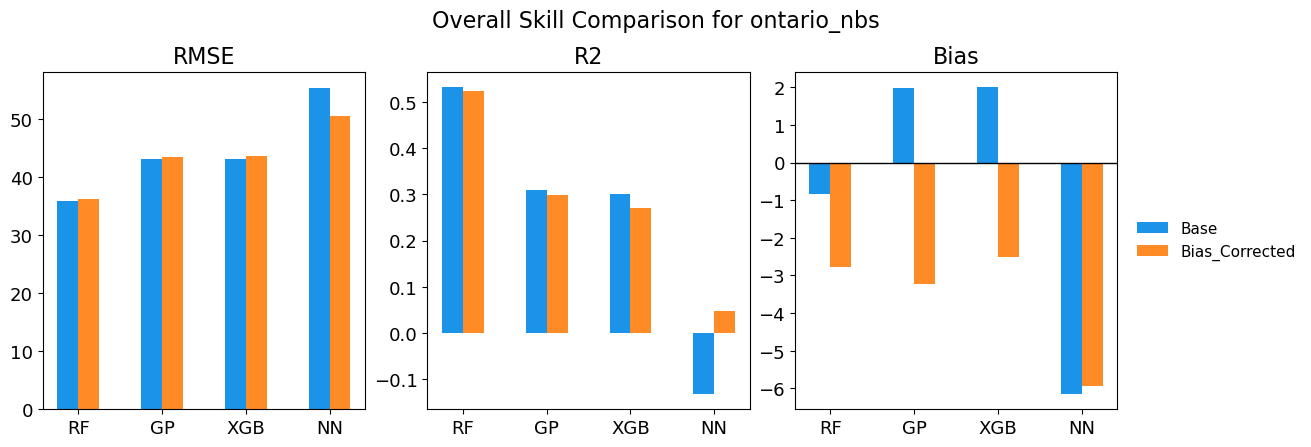

In [11]:
# =========================
# Plot grouped bars
# =========================
metrics = ["RMSE", "R2", "Bias"]
versions = list(csv_files.keys())

plot_df = (
    metrics_df
    .groupby(["version", "model"], as_index=False)[metrics]
    .mean()
)

fig, axes = plt.subplots(
    1, len(metrics),
    figsize=(13, 4),
    constrained_layout=True
)

x = np.arange(len(models))

bar_width = min(0.8 / len(versions), 0.25)

for ax, metric in zip(axes, metrics):
    for i, version in enumerate(versions):
        values = (
            plot_df[plot_df["version"] == version]
            .set_index("model")
            .reindex(models)[metric]
        )

        offset = (i - (len(versions) - 1) / 2) * bar_width

        ax.bar(
            x + offset,
            values,
            width=bar_width,
            label=version,
            color=version_colors[version]
        )

    ax.set_title(metric, fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=13)
    ax.tick_params(axis="y", labelsize=13)

    if metric == "Bias":
        ax.axhline(0, color="black", linewidth=1)

axes[-1].legend(
    fontsize=11,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

fig.suptitle(
    f"Overall Skill Comparison for {forecast_col}",
    fontsize=16,
    y=1.08
)

plt.show()

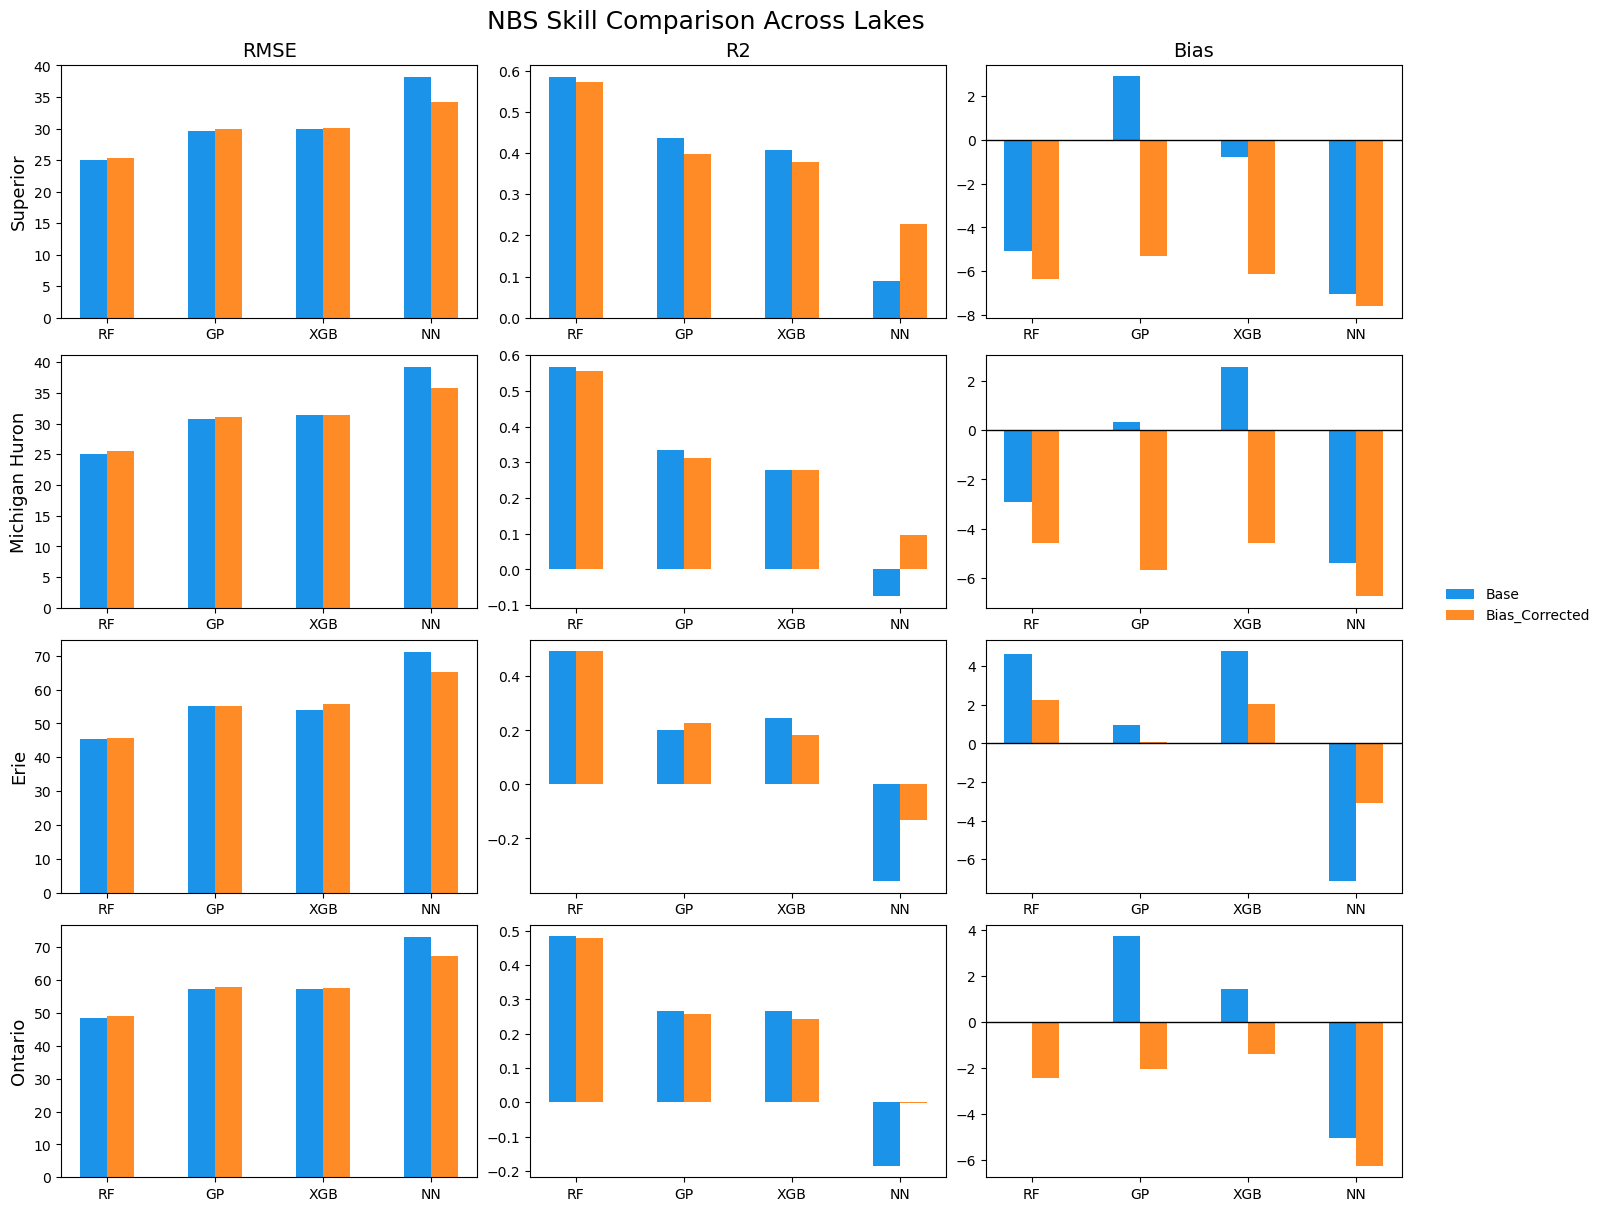

In [13]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ["RMSE", "R2", "Bias"]
versions = list(csv_files.keys())

plot_df = (
    metrics_df
    .groupby(["version", "lake", "model"], as_index=False)[metrics]
    .mean()
)

fig, axes = plt.subplots(
    len(lakes),
    len(metrics),
    figsize=(14, 12),
    constrained_layout=True
)

x = np.arange(len(models))
bar_width = min(0.8 / len(versions), 0.25)

for row, lake in enumerate(lakes):

    for col, metric in enumerate(metrics):

        ax = axes[row, col]

        for i, version in enumerate(versions):

            values = (
                plot_df[
                    (plot_df["lake"] == lake) &
                    (plot_df["version"] == version)
                ]
                .set_index("model")
                .reindex(models)[metric]
            )

            offset = (i - (len(versions) - 1) / 2) * bar_width

            ax.bar(
                x + offset,
                values,
                width=bar_width,
                color=version_colors[version],
                label=version if row == 0 and col == 0 else None
            )

        ax.set_xticks(x)
        ax.set_xticklabels(models)

        if metric == "Bias":
            ax.axhline(0, color="black", linewidth=1)

        if row == 0:
            ax.set_title(metric, fontsize=14)

        if col == 0:
            ax.set_ylabel(lake.replace("-", " ").title(), fontsize=13)

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

fig.suptitle(
    "NBS Skill Comparison Across Lakes",
    fontsize=18
)

plt.show()


In [14]:
lakes = ["superior", "michigan-huron", "erie", "ontario"]
models = ["RF", "GP", "XGB", "NN"]

def calculate_overall_nbs_metrics(df, lakes, model):
    df_model = df[df["model"] == model].copy()

    y_true_all = []
    y_pred_all = []

    for lake in lakes:
        forecast_col = f"{lake}_nbs"
        obs_col = f"{lake}_nbs_obs"

        valid = df_model[forecast_col].notna() & df_model[obs_col].notna()

        y_pred_all.append(df_model.loc[valid, forecast_col])
        y_true_all.append(df_model.loc[valid, obs_col])

    y_pred = pd.concat(y_pred_all, ignore_index=True)
    y_true = pd.concat(y_true_all, ignore_index=True)

    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "Bias": np.mean(y_pred - y_true),
    }

In [15]:
results = []

for version_name, path in csv_files.items():
    df = pd.read_csv(path, sep='\t')

    for model in models:
        metrics = calculate_overall_nbs_metrics(
            df=df,
            lakes=lakes,
            model=model
        )

        results.append({
            "version": version_name,
            "model": model,
            **metrics
        })

overall_nbs_metrics_df = pd.DataFrame(results)

print(overall_nbs_metrics_df)

          version model        RMSE        R2       Bias
0            Base    RF   82.791314  0.589684   1.336750
1            Base    GP   98.014437  0.424918   3.902494
2            Base   XGB   98.364250  0.420806   4.588583
3            Base    NN  126.985364  0.034713 -18.405625
4  Bias_Corrected    RF   83.503211  0.585289  -2.948854
5  Bias_Corrected    GP   99.720245  0.408567  -4.348856
6  Bias_Corrected   XGB   99.455520  0.411703  -1.354715
7  Bias_Corrected    NN  116.412042  0.194001 -12.052596


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# =========================
# Inputs
# =========================

components = [
    "nbs",
    "precipitation",
    "evaporation",
    "runoff"
]

metrics_to_plot = ["RMSE", "R2", "Bias"]

component_titles = {
    "nbs": "NBS",
    "precipitation": "Precipitation",
    "evaporation": "Evaporation",
    "runoff": "Runoff",
}

# =========================
# Metric Functions
# =========================
def calculate_metrics(y_true, y_pred):
    valid = y_true.notna() & y_pred.notna()

    y_true = y_true[valid]
    y_pred = y_pred[valid]

    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "Bias": np.mean(y_pred - y_true),
    }


def calculate_overall_component_metrics(df, lakes, component, model):
    """
    Calculate overall component skill across all lakes by pooling all
    lake-level forecast/observation pairs into one vector.

    This does NOT average metrics across lakes.
    """

    df_model = df[df["model"] == model].copy()

    y_true_all = []
    y_pred_all = []

    for lake in lakes:
        forecast_col = f"{lake}_{component}"
        obs_col = f"{lake}_{component}_obs"

        if forecast_col not in df_model.columns:
            raise KeyError(f"Missing forecast column: {forecast_col}")

        if obs_col not in df_model.columns:
            raise KeyError(f"Missing observation column: {obs_col}")

        valid = (
            df_model[forecast_col].notna()
            & df_model[obs_col].notna()
        )

        y_pred_all.append(df_model.loc[valid, forecast_col])
        y_true_all.append(df_model.loc[valid, obs_col])

    y_pred = pd.concat(y_pred_all, ignore_index=True)
    y_true = pd.concat(y_true_all, ignore_index=True)

    return calculate_metrics(y_true, y_pred)


# =========================
# Calculate Metrics
# =========================
results = []

for version_name, path in csv_files.items():
    df = pd.read_csv(path, sep='\t')

    for component in components:
        for model in models:
            metric_values = calculate_overall_component_metrics(
                df=df,
                lakes=lakes,
                component=component,
                model=model,
            )

            results.append({
                "version": version_name,
                "component": component,
                "model": model,
                **metric_values
            })

metrics_df = pd.DataFrame(results)

print(metrics_df)


           version      component model        RMSE        R2       Bias
0             Base            nbs    RF   82.791314  0.589684   1.336750
1             Base            nbs    GP   98.014437  0.424918   3.902494
2             Base            nbs   XGB   98.364250  0.420806   4.588583
3             Base            nbs    NN  126.985364  0.034713 -18.405625
4             Base  precipitation    RF   25.628017  0.104241  -1.730571
5             Base  precipitation    GP   31.625076 -0.364031   4.309900
6             Base  precipitation   XGB   32.418989 -0.433375   2.079809
7             Base  precipitation    NN   40.964301 -1.288612  -3.378392
8             Base    evaporation    RF   15.633006  0.886190  -2.561544
9             Base    evaporation    GP   19.198609  0.828354   0.139483
10            Base    evaporation   XGB   18.916984  0.833353  -0.738251
11            Base    evaporation    NN   24.583715  0.718558   3.229649
12            Base         runoff    RF   28.510785

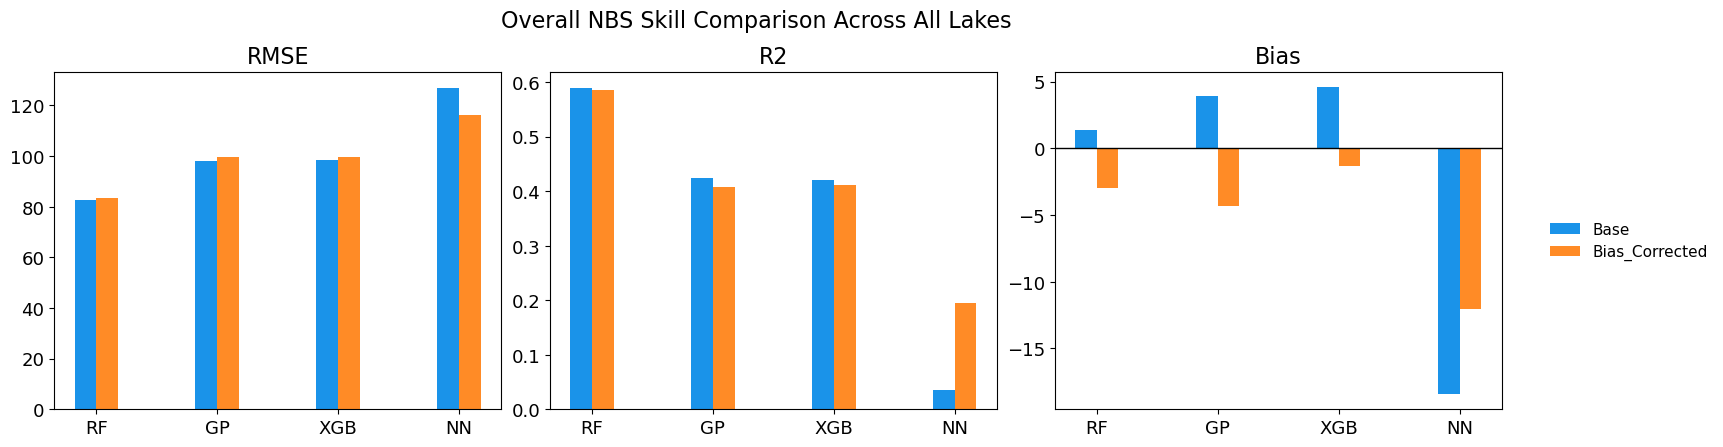

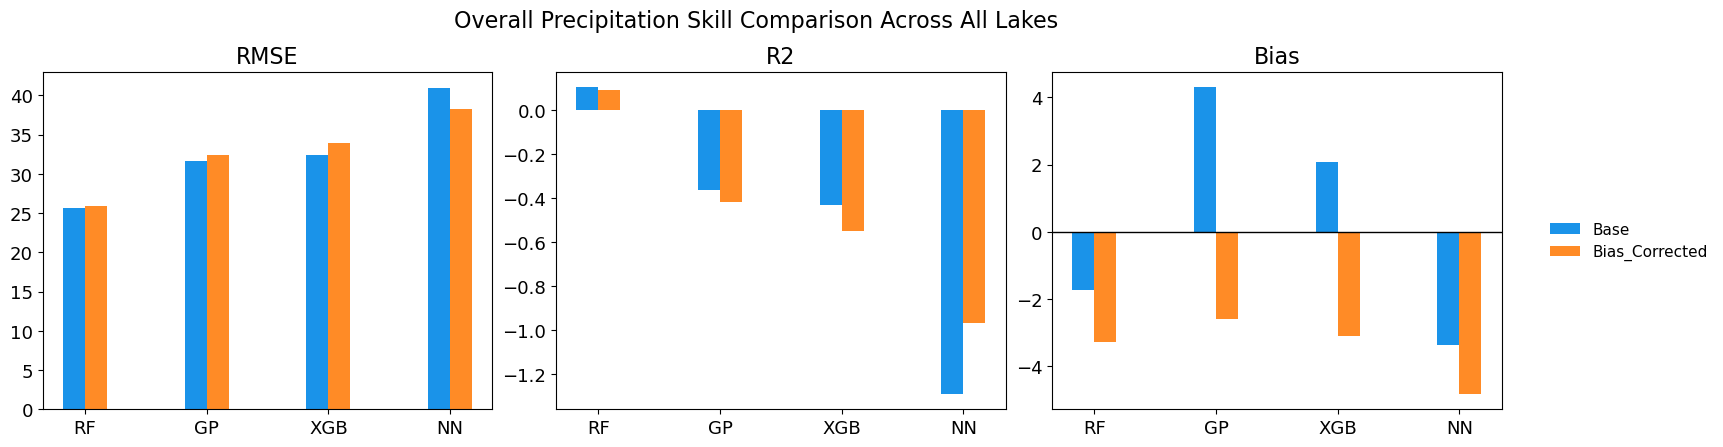

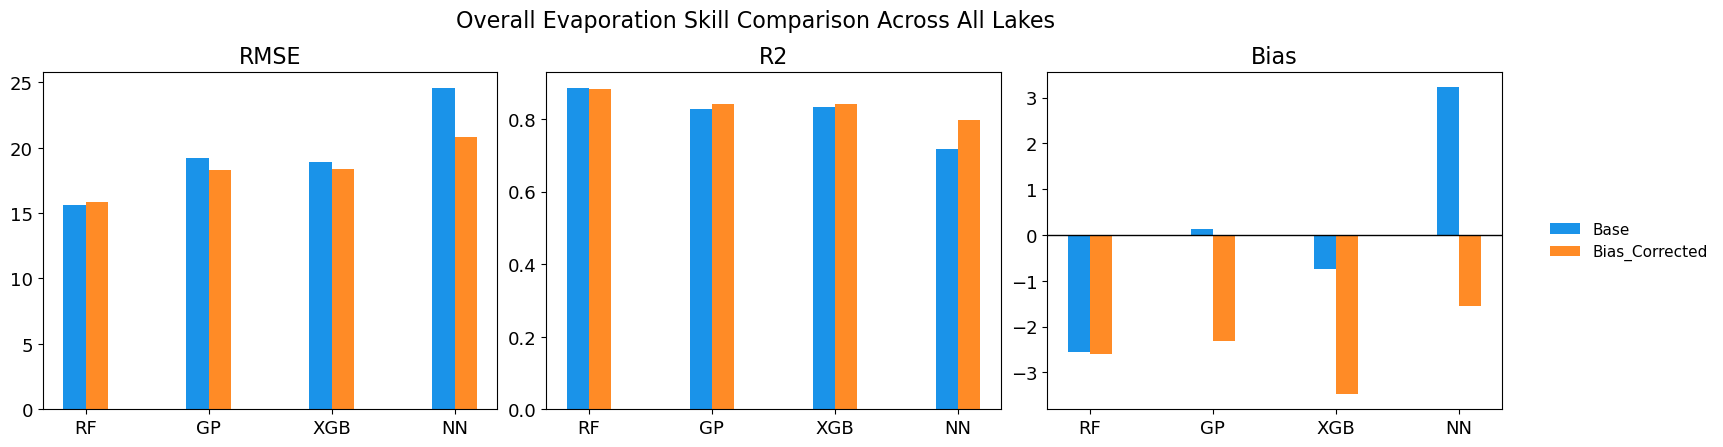

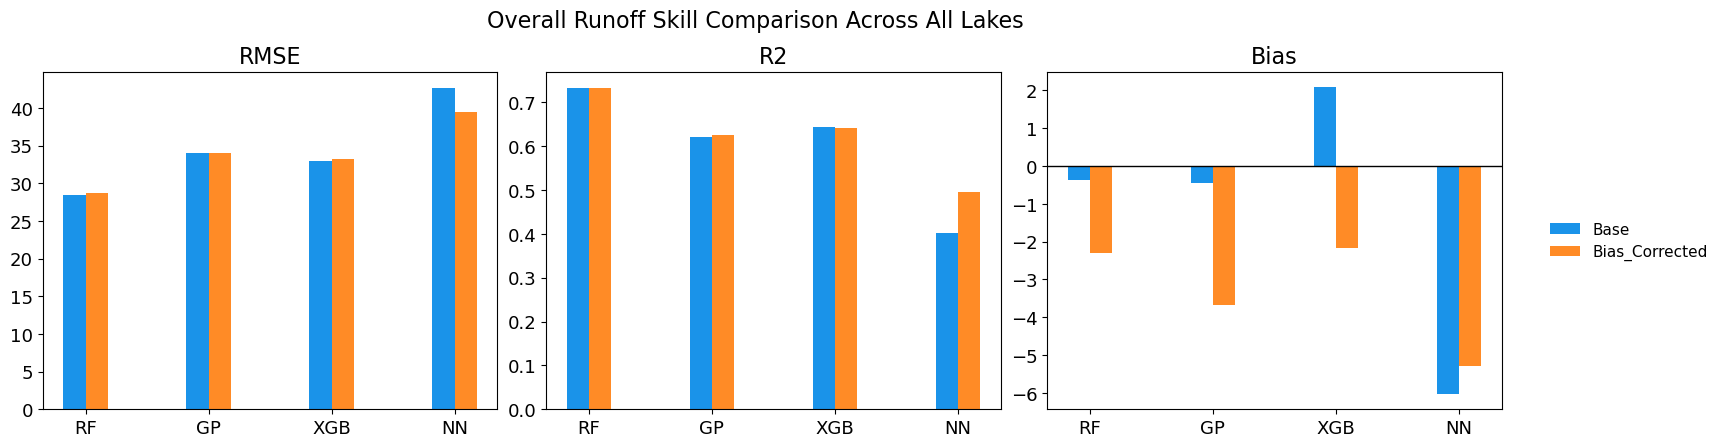

In [17]:

# =========================
# Plot One Figure per Component
# =========================
versions = list(csv_files.keys())

x = np.arange(len(models))
bar_width = 0.18

for component in components:

    component_df = metrics_df[metrics_df["component"] == component]

    fig, axes = plt.subplots(
        1, 3,
        figsize=(15, 4),
        constrained_layout=True
    )

    for ax, metric in zip(axes, metrics_to_plot):

        for i, version in enumerate(versions):

            values = (
                component_df[
                    component_df["version"] == version
                ]
                .set_index("model")
                .loc[models, metric]
            )

            offset = (i - (len(versions) - 1) / 2) * bar_width

            ax.bar(
                x + offset,
                values,
                width=bar_width,
                label=version,
                color=version_colors[version]
            )

        ax.set_title(metric, fontsize=16)
        ax.set_xticks(x)
        ax.set_xticklabels(models, fontsize=13)
        ax.tick_params(axis="y", labelsize=13)

        if metric == "Bias":
            ax.axhline(0, color="black", linewidth=1)

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=11
    )

    fig.suptitle(
        f"Overall {component_titles[component]} Skill Comparison Across All Lakes",
        fontsize=16,
        y=1.08
    )

    plt.show()